<a href="https://colab.research.google.com/github/parulgoell/ai-attendance-agent/blob/main/traffic_light_optimizer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

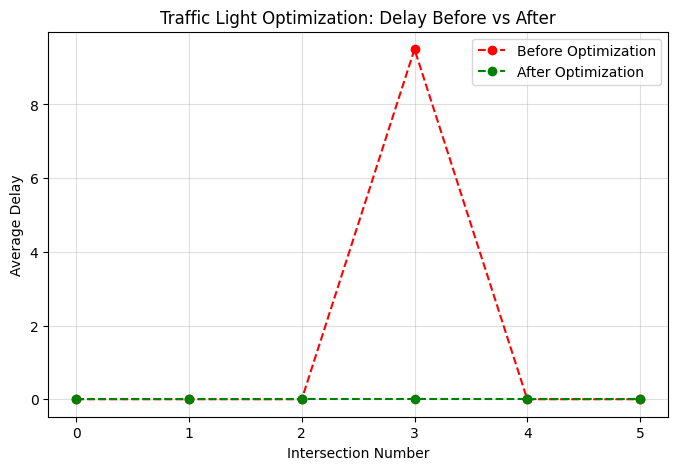

In [ ]:
# -------------------------------------------------------
# Traffic Light Optimization : Rule-Based Delay Reduction
# -------------------------------------------------------

import numpy as np                       # For numerical operations and random traffic simulation
import matplotlib.pyplot as plt          # For plotting delay graph before vs after optimization

# -----------------------------
# 1. Simulation Setup
# -----------------------------

np.random.seed(0)                        # Fix random generation so results are reproducible

num_intersections = 6                    # Number of traffic lights/intersections to simulate
sim_time = 50                            # Number of time steps in the simulation

# Random incoming traffic volume (vehicles per minute) for each intersection
traffic_flow = np.random.randint(10, 50, num_intersections)

# Base green light duration for all intersections (in seconds)
base_green_time = 30

# Store recorded delays before and after optimization
delays_before = np.zeros(num_intersections)
delays_after = np.zeros(num_intersections)

# -----------------------------
# 2. Delay Calculation Function
# -----------------------------

def calculate_delay(flow, green_time):
    """
    flow       → vehicles arriving per minute
    green_time → seconds allowed for them to pass
    return     → average delay (lower = better)
    """

    # Convert green time in seconds into vehicles that can pass (1 veh/sec capacity)
    capacity = green_time

    # If demand exceeds capacity, extra vehicles wait
    waiting = max(0, flow - capacity)

    # Delay proportional to how many vehicles were stuck
    delay = waiting * 0.5                  # 0.5 = delay penalty per waiting vehicle

    return delay

# -----------------------------
# 3. Baseline Delays (Before Optimization)
# -----------------------------

for i in range(num_intersections):        # Loop through each intersection
    delays_before[i] = calculate_delay(
        traffic_flow[i],                  # Vehicles arriving
        base_green_time                   # Base timing for all lights
    )

# -----------------------------
# 4. Rule-Based Optimization
# -----------------------------

# Simple policy:
#   If traffic is high → give more green time
#   If traffic is low → give less green time

optimized_green_times = np.zeros(num_intersections)

for i in range(num_intersections):
    flow = traffic_flow[i]                # Get traffic volume at this intersection

    if flow > 40:                         # Very heavy traffic
        optimized_green_times[i] = base_green_time + 20
    elif flow > 30:                       # Heavy traffic
        optimized_green_times[i] = base_green_time + 10
    elif flow < 20:                       # Light traffic
        optimized_green_times[i] = base_green_time - 10
    else:                                 # Medium traffic
        optimized_green_times[i] = base_green_time

# -----------------------------
# 5. Delays After Optimization
# -----------------------------

for i in range(num_intersections):
    delays_after[i] = calculate_delay(
        traffic_flow[i],                  # Traffic flow stays same
        optimized_green_times[i]          # New adaptive green time
    )

# -----------------------------
# 6. Output Graph: Before vs After
# -----------------------------

x = np.arange(num_intersections)          # X-axis labels = intersection indices

plt.figure(figsize=(8, 5))                # Set chart size

plt.plot(x, delays_before, 'ro--', label='Before Optimization') # Red dotted line for baseline delay
plt.plot(x, delays_after, 'go--', label='After Optimization')   # Green dotted line for improved delay

plt.xlabel("Intersection Number")         # Label for x-axis
plt.ylabel("Average Delay")               # Label for y-axis
plt.title("Traffic Light Optimization: Delay Before vs After") # Chart title

plt.legend()                              # Show legend
plt.grid(alpha=0.4)                       # Add soft grid for readability
plt.show()                                # Display the graph
